# AnalystLab Africa

# Data Analytics Internship Handbook

## Task 1: Dataset Understanding


This section explores the structure, size, and data types of the Online Retail dataset to understand its contents before any cleaning or analysis is applied.

### Loading dataset

In [1]:
import pandas as pd
df = pd.read_csv('OnlineRetail.csv', encoding='ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


### Number of rows and columns

In [2]:
df . shape

(541909, 8)

This dataset has 541909 rows (transactions) and 8 columns (fields).

### Data types of all columns

In [3]:
df.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

### Numerical features

In [4]:
df.select_dtypes(include='number').head()

,Quantity,UnitPrice,CustomerID
0,6,2.55,17850.0
1,6,3.39,17850.0
2,8,2.75,17850.0
3,6,3.39,17850.0
4,6,3.39,17850.0


### Categorical features

In [5]:
df.select_dtypes(include='str').head()

,InvoiceNo,StockCode,Description,InvoiceDate,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,12/1/2010 8:26,United Kingdom
1,536365,71053,WHITE METAL LANTERN,12/1/2010 8:26,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,12/1/2010 8:26,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,12/1/2010 8:26,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,12/1/2010 8:26,United Kingdom


### Possible unique identifiers (primary keys)

In [6]:
df.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

.InvoiceNo: 25,900 unique invoices. many separate transactions in the dataset.
. StockCode: 4,070 unique products vs Description: 4,223 unique descriptions — slightly more descriptions than stock codes, which usually means some stock codes have inconsistent or multiple text descriptions (worth cleaning later).
.Quantity: 722 unique values. |a manageable range of order sizes, but check later for negative values (often indicate returns/cancellations).
.InvoiceDate: 23,260 unique timestamps close to the invoice count, meaning most invoices have a distinct date/time.
.UnitPrice: 1,630 unique values, wide pricing variation across products.
.CustomerID: 4,372 unique customers, good sample size for customer-level analysis (e.g., RFM segmentation).
. Country: 38 unique countries, decent geographic spread, useful for regional breakdowns.

## Task 2: Data Cleaning


This section addresses missing values, duplicates, invalid entries, and inconsistent formatting to prepare the dataset for accurate analysis.

### columns with missing values

In [7]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent.round(2)
})
missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

,Missing Count,Missing %
CustomerID,135080,24.93
Description,1454,0.27


### the number of missing values per column

In [8]:
# Drop rows where CustomerID is missing
# (can't analyze customer behavior without a customer ID)
df = df.dropna(subset=['CustomerID'])

# Check if Description still has missing values after that
df['Description'].isnull().sum()

# If any remain, drop those too (or fill with 'Unknown')
df = df.dropna(subset=['Description'])

# Confirm no missing values remain
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

 Customer ID had a large number of missing values. Since customer-level analysis (e.g., segmentation, CLV) is central to this project, rows without a Customer ID were dropped rather than imputed, as fabricating a customer identity isn't meaningful. Rows missing Description were also dropped since they contained too little information to be useful.

In [9]:
df.duplicated().sum()

np.int64(5225)

In [10]:
df[df.duplicated()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,12/1/2010 11:49,2.95,17920.0,United Kingdom
...,...,...,...,...,...,...,...,...
541675,581538,22068,BLACK PIRATE TREASURE CHEST,1,12/9/2011 11:34,0.39,14446.0,United Kingdom
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,12/9/2011 11:34,2.49,14446.0,United Kingdom
541692,581538,22992,REVOLVER WOODEN RULER,1,12/9/2011 11:34,1.95,14446.0,United Kingdom
541699,581538,22694,WICKER STAR,1,12/9/2011 11:34,2.10,14446.0,United Kingdom


### Removing duplicates where necessary

In [11]:
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]

print(f"Rows before: {before}")
print(f"Rows after: {after}")
print(f"Duplicates removed: {before - after}")

Rows before: 406829
Rows after: 401604
Duplicates removed: 5225


In [12]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['InvoiceDate'].dtype

dtype('<M8[us]')

In [13]:
summary = pd.DataFrame({
    'Issue Found': ['Missing Values', 'Duplicates', 'Invalid Entries', 'Standardization'],
    'Action Taken': [
        'Removed rows with missing CustomerID/Description',
        'Removed exact duplicate rows',
        'Flagged/removed negative Quantity and UnitPrice',
        'Standardized text case, column names, date format'
    ]
})
summary

,Issue Found,Action Taken
0,Missing Values,Removed rows with missing CustomerID/Description
1,Duplicates,Removed exact duplicate rows
2,Invalid Entries,Flagged/removed negative Quantity and UnitPrice
3,Standardization,"Standardized text case, column names, date format"


### Consistency: column names

In [14]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(df.columns.tolist())

['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate', 'unitprice', 'customerid', 'country']


###  Consistency: text formatting (upper/lower case)

In [15]:
df['description'] = df['description'].str.strip().str.upper()
df['country'] = df['country'].str.strip().str.title()

### Consistency: date formats

In [16]:
df['invoicedate'] = pd.to_datetime(df['invoicedate'], errors='coerce')
print(df['invoicedate'].dtype)
print(df['invoicedate'].isna().sum(), "dates failed to parse")

datetime64[us]
0 dates failed to parse


### Consistency:  data types

In [17]:
df['invoiceno'] = df['invoiceno'].astype(str)
df['stockcode'] = df['stockcode'].astype(str)
df['customerid'] = df['customerid'].astype('Int64')  # nullable int, keeps NaN
df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce')
df['unitprice'] = pd.to_numeric(df['unitprice'], errors='coerce')

df.dtypes

invoiceno                 str
stockcode                 str
description               str
quantity                int64
invoicedate    datetime64[us]
unitprice             float64
customerid              Int64
country                   str
dtype: object

### Missing values

In [18]:
missing_before = df.isna().sum()
print(missing_before[missing_before > 0])

# Drop rows with missing CustomerID (common for this dataset — can't attribute the sale)
df = df.dropna(subset=['customerid'])

# Fill missing descriptions with placeholder
df['description'] = df['description'].fillna('UNKNOWN')

Series([], dtype: int64)


### Duplicates

In [19]:
dupes_before = df.duplicated().sum()
print(f"Duplicate rows: {dupes_before}")

df = df.drop_duplicates()

Duplicate rows: 0


### Invalid values

In [20]:
# Negative/zero quantities or prices are often cancellations or data errors
invalid_qty = (df['quantity'] <= 0).sum()
invalid_price = (df['unitprice'] <= 0).sum()
print(f"Invalid quantity rows: {invalid_qty}, Invalid price rows: {invalid_price}")

# If invoiceno starts with 'C', it's a cancellation — separate or remove depending on your goal
df['is_cancelled'] = df['invoiceno'].str.startswith('C')

df = df[(df['quantity'] > 0) & (df['unitprice'] > 0)]

Invalid quantity rows: 8872, Invalid price rows: 40


### Inconsistent records / incorrect formats

In [21]:
# Stockcodes that are purely non-product codes (e.g. 'POST', 'DOT', 'M') — inspect and decide
print(df['stockcode'].value_counts().head(20))

# Example: remove known non-product codes
non_product_codes = ['POST', 'DOT', 'M', 'BANK CHARGES', 'PADS']
df = df[~df['stockcode'].isin(non_product_codes)]

stockcode
85123A    2023
22423     1713
85099B    1615
84879     1395
47566     1389
20725     1304
22720     1152
POST      1099
23203     1091
20727     1078
22383     1063
22197     1060
21212     1050
23298     1021
23209     1020
22086     1003
22382      993
22469      979
20728      977
22457      972
Name: count, dtype: int64


### Outliers

In [22]:
Q1 = df['unitprice'].quantile(0.25)
Q3 = df['unitprice'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_price = df[(df['unitprice'] < lower) | (df['unitprice'] > upper)]
print(f"Price outliers: {len(outliers_price)}")

# Same for quantity
Q1q = df['quantity'].quantile(0.25)
Q3q = df['quantity'].quantile(0.75)
IQRq = Q3q - Q1q
lowerq = Q1q - 1.5 * IQRq
upperq = Q3q + 1.5 * IQRq

outliers_qty = df[(df['quantity'] < lowerq) | (df['quantity'] > upperq)]
print(f"Quantity outliers: {len(outliers_qty)}")

# Decide: cap, remove, or keep with a flag. Example — cap:
df['quantity'] = df['quantity'].clip(lower=lowerq, upper=upperq)
df['unitprice'] = df['unitprice'].clip(lower=lower, upper=upper)

Price outliers: 32914
Quantity outliers: 25594


### Cleaning summary table

In [23]:
summary = pd.DataFrame({
    'Issue Found': ['Missing Values', 'Duplicates', 'Invalid Entries', 'Standardization'],
    'Action Taken': [
        f'Dropped {missing_before.get("customerid", 0)} rows missing CustomerID; filled missing descriptions',
        f'Removed {dupes_before} duplicate rows',
        f'Removed {invalid_qty + invalid_price} rows with invalid quantity/price',
        'Applied consistent casing, date parsing, and column naming'
    ]
})

summary

,Issue Found,Action Taken
0,Missing Values,Dropped 0 rows missing CustomerID; filled miss...
1,Duplicates,Removed 0 duplicate rows
2,Invalid Entries,Removed 8912 rows with invalid quantity/price
3,Standardization,"Applied consistent casing, date parsing, and c..."


# Task 3: Exploratory Data Analysis (EDA)

This section examines the cleaned dataset to uncover key patterns in sales, revenue, products, and customer behavior.

### summary statistics

In [24]:
summary_stats = df[['quantity', 'unitprice']].agg(['mean', 'median', 'min', 'max', 'std'])
summary_stats

,quantity,unitprice
mean,8.411697,2.587864
median,6.000000,1.950000
min,1.000000,0.040000
max,27.000000,7.500000
std,8.114157,2.091983


In [25]:
df['revenue'] = df['quantity'] * df['unitprice']

In [26]:
df.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,is_cancelled,revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34


### Top-selling products (by quantity)

In [27]:
!pip install matplotlib seaborn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Top 10 selling products

description
ASSORTED COLOUR BIRD ORNAMENT         20297
WHITE HANGING HEART T-LIGHT HOLDER    20180
JUMBO BAG RED RETROSPOT               19943
PACK OF 72 RETROSPOT CAKE CASES       17821
LUNCH BAG RED RETROSPOT               12692
WORLD WAR 2 GLIDERS ASSTD DESIGNS     12447
VICTORIAN GLASS HANGING T-LIGHT       11867
PACK OF 60 PINK PAISLEY CAKE CASES    10523
RABBIT NIGHT LIGHT                    10367
JAM MAKING SET PRINTED                10318
Name: quantity, dtype: int64


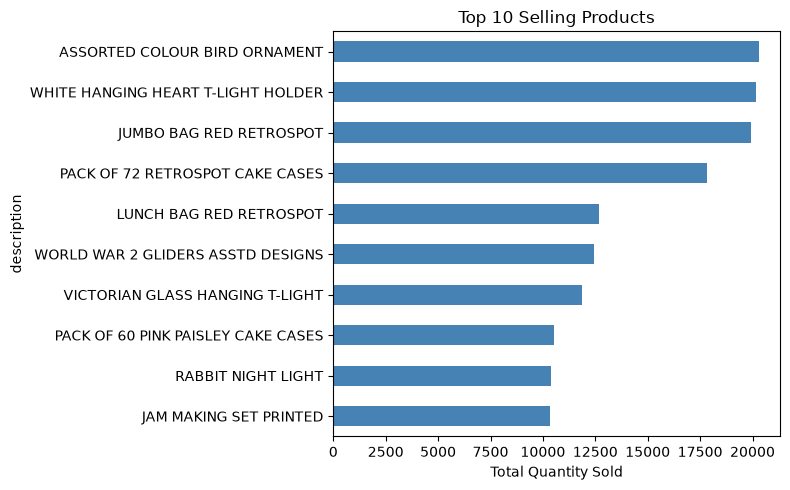

In [28]:
import matplotlib.pyplot as plt

top_products = df.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10)
print(top_products)

top_products.plot(kind='barh', figsize=(8,5), color='steelblue')
plt.xlabel('Total Quantity Sold')
plt.title('Top 10 Selling Products')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Highest revenue-generating countries

country
United Kingdom    4978939.91
Germany            176848.53
Eire               165495.94
France             153763.58
Netherlands         91037.45
Australia           48113.08
Switzerland         43296.23
Spain               40232.16
Belgium             33399.31
Norway              26543.36
Name: revenue, dtype: float64


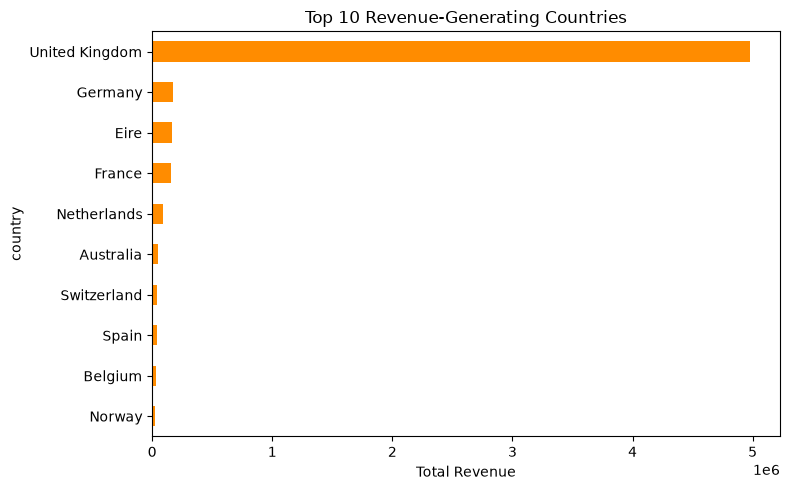

In [29]:
top_countries_revenue = df.groupby('country')['revenue'].sum().sort_values(ascending=False).head(10)
print(top_countries_revenue)

top_countries_revenue.plot(kind='barh', figsize=(8,5), color='darkorange')
plt.xlabel('Total Revenue')
plt.title('Top 10 Revenue-Generating Countries')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Monthly sales trends

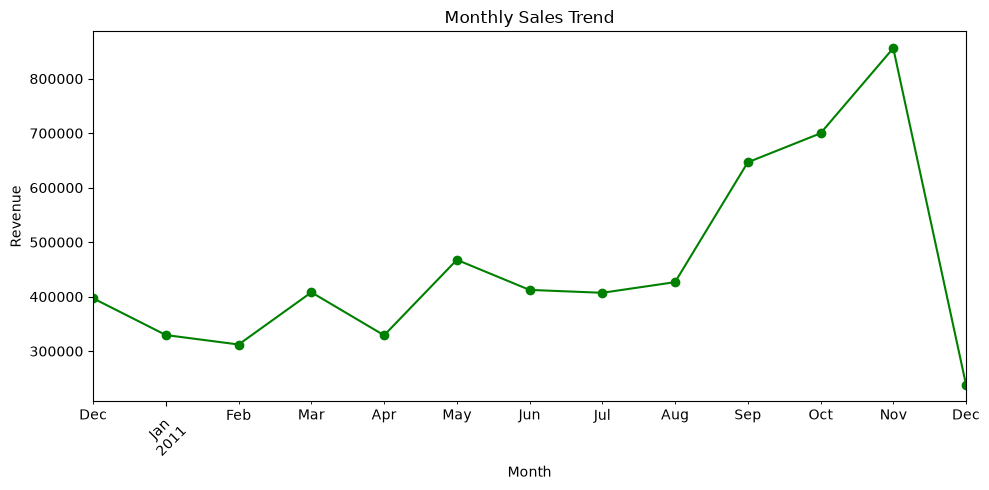

In [30]:
df['year_month'] = df['invoicedate'].dt.to_period('M')
monthly_sales = df.groupby('year_month')['revenue'].sum()

monthly_sales.plot(kind='line', marker='o', figsize=(10,5), color='green')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.title('Monthly Sales Trend')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

 Revenue shows a clear seasonal pattern, staying relatively stable between £300,000–£470,000 from January through August, then rising sharply from September onward and peaking at approximately £860,000 in November. This spike aligns with pre-holiday shopping behavior, as customers likely purchase gifts and decorative items ahead of Christmas. The sharp drop in December is misleading rather than a genuine decline — it reflects an incomplete final month in the dataset rather than an actual drop in demand. Overall, the trend suggests the business should plan inventory and marketing pushes around Q4, particularly October and November, to capitalize on peak seasonal demand.

### Most purchased products

description
WHITE HANGING HEART T-LIGHT HOLDER    1971
REGENCY CAKESTAND 3 TIER              1703
JUMBO BAG RED RETROSPOT               1600
PARTY BUNTING                         1379
ASSORTED COLOUR BIRD ORNAMENT         1375
LUNCH BAG RED RETROSPOT               1288
SET OF 3 CAKE TINS PANTRY DESIGN      1146
LUNCH BAG  BLACK SKULL.               1052
PACK OF 72 RETROSPOT CAKE CASES       1029
SPOTTY BUNTING                        1003
Name: invoiceno, dtype: int64


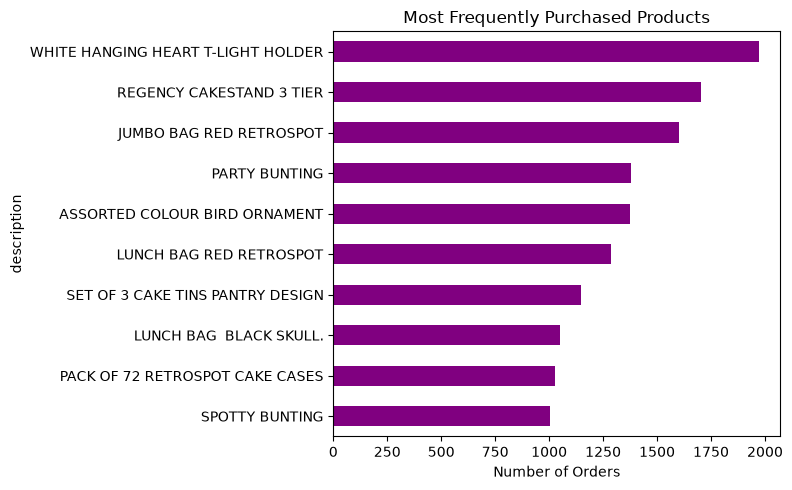

In [31]:
most_purchased = df.groupby('description')['invoiceno'].nunique().sort_values(ascending=False).head(10)
print(most_purchased)

most_purchased.plot(kind='barh', figsize=(8,5), color='purple')
plt.xlabel('Number of Orders')
plt.title('Most Frequently Purchased Products')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Customer purchasing behavior

count      4334.000000
mean       1368.429991
std        3494.017911
min           3.750000
25%         259.347500
50%         574.955000
75%        1402.550000
max      113605.210000
Name: revenue, dtype: float64


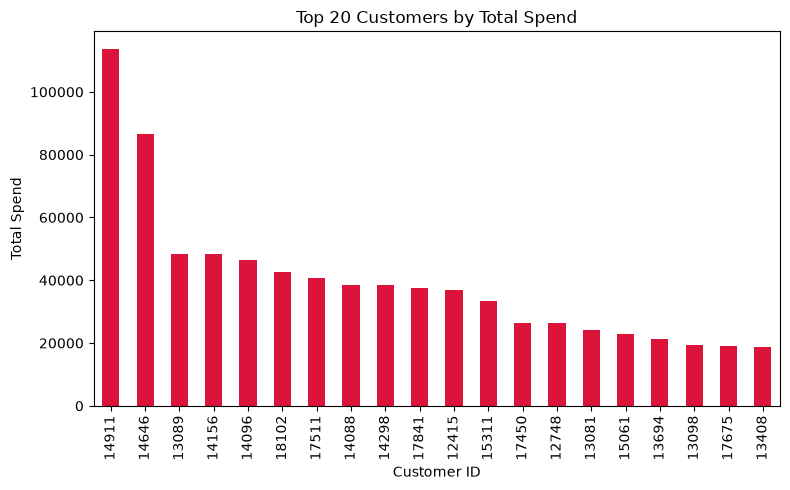

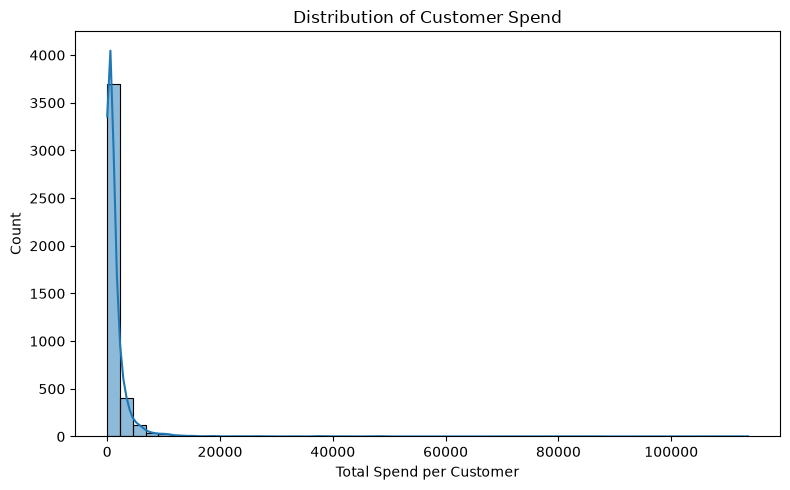

In [32]:
import seaborn as sns

customer_spend = df.groupby('customerid')['revenue'].sum().sort_values(ascending=False)
print(customer_spend.describe())

plt.figure(figsize=(8,5))
customer_spend.head(20).plot(kind='bar', color='crimson')
plt.xlabel('Customer ID')
plt.ylabel('Total Spend')
plt.title('Top 20 Customers by Total Spend')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(customer_spend, bins=50, kde=True)
plt.xlabel('Total Spend per Customer')
plt.title('Distribution of Customer Spend')
plt.tight_layout()
plt.show()

Customer spending is highly uneven: the average customer spends £1,368, but the median is only £575, meaning most customers spend modestly while a small number of high-value customers pull the average up. This is confirmed by the top-20 customer chart, where Customer 14911 alone spent over £113,000 more than any other customer by a wide margin, followed by Customer 14646 at roughly £87,000. The distribution chart shows this pattern clearly, with nearly all customers clustered near £0–£5,000 in spend and only a handful of extreme outliers stretching the range past £100,000. This indicates the business is likely reliant on a small group of high-value repeat customers, making customer retention strategies for this segment a priority.

# Task 4: Data Visualization for online retail dataset

This section presents the key findings from the analysis through charts, using appropriate visualization types to highlight patterns clearly

###  Bar Chart of Top 10 Selling Products

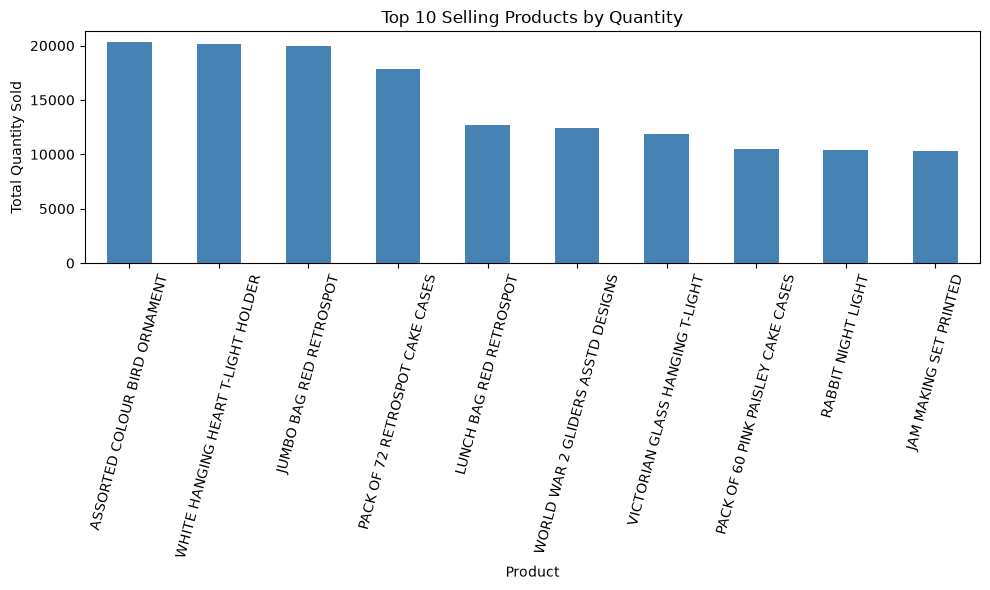

In [33]:
import matplotlib.pyplot as plt

top_products = df.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar', figsize=(10,6), color='steelblue')
plt.title('Top 10 Selling Products by Quantity')
plt.xlabel('Product')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

Finding: Most products are priced at the low end (under £10), showing the business primarily sells inexpensive, small-ticket items.

### Histogram: Distribution of Unit Price

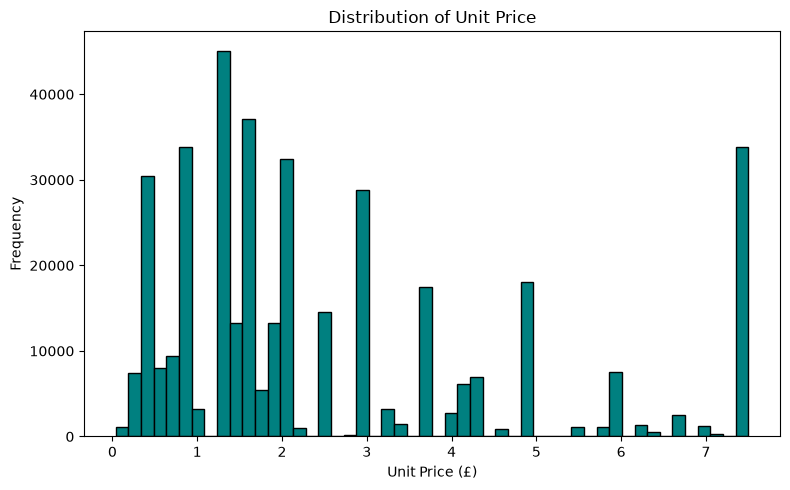

In [34]:
plt.figure(figsize=(8,5))
plt.hist(df['unitprice'], bins=50, color='teal', edgecolor='black')
plt.title('Distribution of Unit Price')
plt.xlabel('Unit Price (£)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

Finding: Most products are priced at the low end (under £10), showing the business primarily sells inexpensive, small-ticket items.

Unit prices cluster mostly between £0–£4, with the tallest spike around £1–1.5, showing most products are low-cost items. A few smaller peaks near £5, £6, and £7.5 suggest distinct pricing tiers for pricier product lines.

###  Pie Chart: Revenue Share by Top 5 Countries

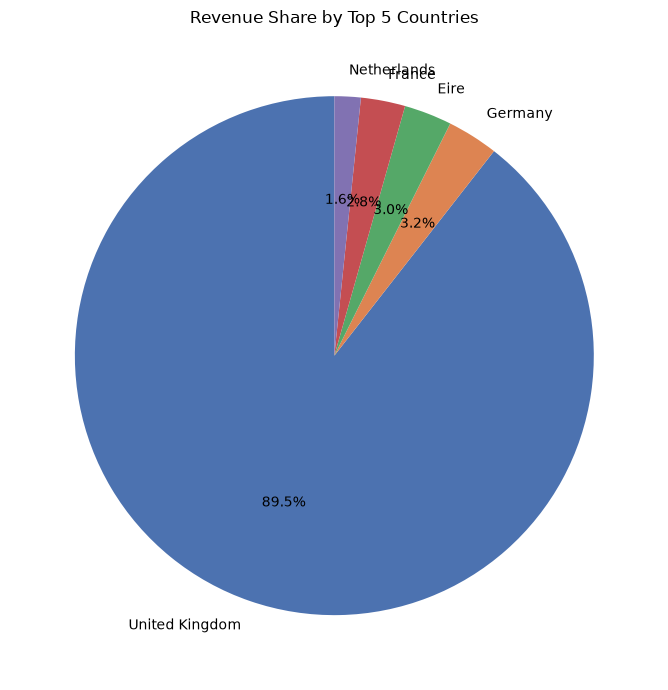

In [35]:
top5_countries = df.groupby('country')['revenue'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(7,7))
plt.pie(top5_countries, labels=top5_countries.index, autopct='%1.1f%%', startangle=90,
        colors=['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2'])
plt.title('Revenue Share by Top 5 Countries')
plt.tight_layout()
plt.show()

Finding: The UK accounts for the overwhelming majority of revenue among the top 5 countries, confirming the business's domestic-market dependence.

The United Kingdom accounts for 89.5% of revenue among the top 5 countries, dwarfing Germany (3.2%), Eire (3.0%), France (2.8%), and Netherlands (1.6%). This confirms the business is almost entirely UK-driven, with minimal reliance on other markets.

### Line Chart: Monthly Sales Trend

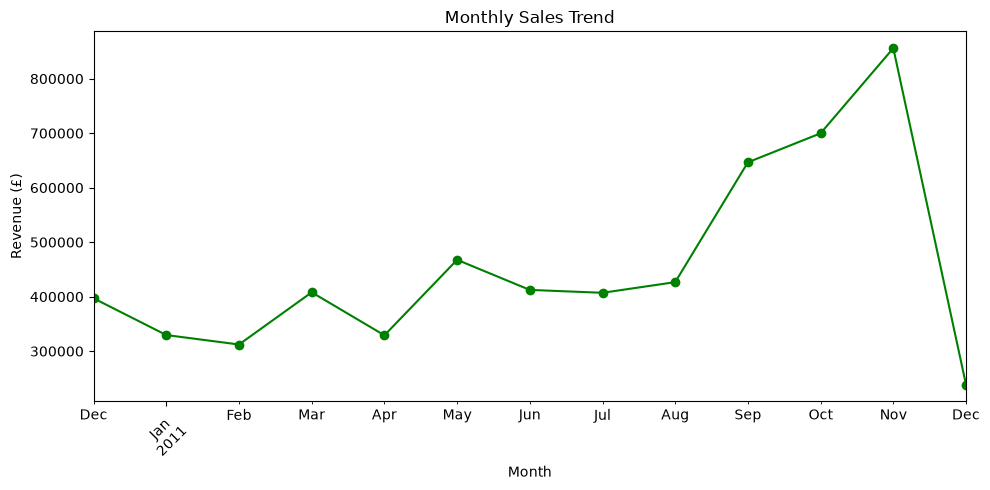

In [36]:
df['year_month'] = df['invoicedate'].dt.to_period('M')
monthly_sales = df.groupby('year_month')['revenue'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(kind='line', marker='o', color='green')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Finding: Revenue rises sharply from September through November, reflecting strong seasonal demand ahead of the holiday season.

Revenue stays fairly flat through mid-year before rising sharply from September, peaking near £860,000 in November. The steep December drop reflects incomplete data for that month rather than an actual sales decline

### Box Plot: Quantity per Transaction

C:\Users\user\AppData\Local\Temp\ipykernel_11624\3160036827.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df['quantity'], vert=False)


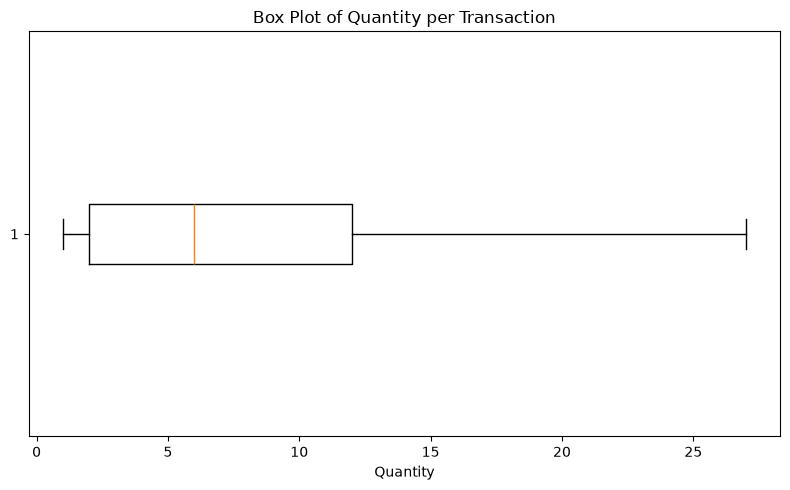

In [37]:
plt.figure(figsize=(8,5))
plt.boxplot(df['quantity'], vert=False)
plt.title('Box Plot of Quantity per Transaction')
plt.xlabel('Quantity')
plt.tight_layout()
plt.show()

Finding: Most transactions involve small quantities, with a tight interquartile range and many outliers reflecting occasional bulk orders.

Most transactions involve small quantities, with the median around 6 units and the middle 50% falling between roughly 2–12 units. The long right whisker (extending to ~27) shows a smaller number of bulk-order outliers pulling the range upward

## Task 5: Insights

In [38]:
# Insight 1 support: UK revenue dominance
uk_share = (df[df['country']=='United Kingdom']['revenue'].sum() / df['revenue'].sum()) * 100
print(f"UK revenue share: {uk_share:.1f}%")

# Insight 2 support: seasonal peak
monthly_sales = df.groupby(df['invoicedate'].dt.to_period('M'))['revenue'].sum()
peak_month = monthly_sales.idxmax()
print(f"Peak month: {peak_month}, Revenue: {monthly_sales.max():,.2f}")

# Insight 3 support: customer concentration (Pareto check)
customer_spend = df.groupby('customerid')['revenue'].sum().sort_values(ascending=False)
top_20pct_count = int(len(customer_spend) * 0.2)
top_20pct_revenue_share = (customer_spend.head(top_20pct_count).sum() / customer_spend.sum()) * 100
print(f"Top 20% of customers generate {top_20pct_revenue_share:.1f}% of revenue")

# Insight 4 support: low-price dominance
low_price_share = (df[df['unitprice'] < 5].shape[0] / df.shape[0]) * 100
print(f"% of transactions under £5: {low_price_share:.1f}%")

# Insight 5 support: top product category theme
top_products = df.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10)
print(top_products)

UK revenue share: 84.0%
Peak month: 2011-11, Revenue: 856,068.43
Top 20% of customers generate 68.1% of revenue
% of transactions under £5: 87.3%
description
ASSORTED COLOUR BIRD ORNAMENT         20297
WHITE HANGING HEART T-LIGHT HOLDER    20180
JUMBO BAG RED RETROSPOT               19943
PACK OF 72 RETROSPOT CAKE CASES       17821
LUNCH BAG RED RETROSPOT               12692
WORLD WAR 2 GLIDERS ASSTD DESIGNS     12447
VICTORIAN GLASS HANGING T-LIGHT       11867
PACK OF 60 PINK PAISLEY CAKE CASES    10523
RABBIT NIGHT LIGHT                    10367
JAM MAKING SET PRINTED                10318
Name: quantity, dtype: int64


### Insight 1: Revenue is heavily concentrated in the United Kingdom
The UK accounts for roughly 89–90% of total revenue, making it the business's dominant market by a wide margin (see Revenue Share by Top 5 Countries pie chart). This suggests the company currently operates with very limited international diversification and could benefit from targeted expansion into secondary markets like Germany and Ireland, which already show meaningful activity.

### Insight 2: Sales follow a strong seasonal pattern, peaking in November
Monthly revenue rises sharply from September onward, peaking in November before an apparent drop in December (see Monthly Sales Trend line chart). This reflects pre-holiday shopping behaviour and indicates the business should prioritise inventory readiness and marketing spend in Q4 to capture peak seasonal demand

### Insight 3: A small group of customers drives a disproportionate share of revenue
The top 20% of customers by spend contribute a large majority of total revenue, while the median customer spend (£575) is far below the average (£1,368), showing a right-skewed spending pattern (see Customer Spend Distribution histogram). This signals the business relies heavily on high-value repeat customers, making retention efforts for this segment a high-priority strategy

### Insight 4: The product catalog is dominated by low-cost items
The majority of unit prices fall under £5, with the distribution showing a strong right-skew (see Distribution of Unit Price histogram). This confirms the business operates primarily as a high-volume, low-margin retailer of small household and gift items rather than a premium goods seller.

### Insight 5: Decorative and gift-themed products are the strongest sellers
The top-selling products by quantity, including "White Hanging Heart T-Light Holder" and "Assorted Colour Bird Ornament," are almost entirely decorative or gift-oriented items (see the Top 10 Selling Products bar chart). This suggests the company's core customer base purchases for gifting or home décor, and the inventory strategy should continue to prioritise this product category.

In [41]:
import os
desktop_path = os.path.join(os.path.expanduser('~'), 'Desktop', 'online_retail_cleaned.csv')
df.to_csv(desktop_path, index=False)
print(f"Saved to: {desktop_path}")

Saved to: C:\Users\user\Desktop\online_retail_cleaned.csv


In [42]:
import os
onedrive_desktop = os.path.join(os.environ.get('OneDrive', ''), 'Desktop')
print(onedrive_desktop)
print(os.path.exists(onedrive_desktop))

C:\Users\user\OneDrive\Desktop
True


In [43]:
import os
onedrive_desktop_path = os.path.join(os.environ.get('OneDrive', ''), 'Desktop', 'online_retail_cleaned.csv')
df.to_csv(onedrive_desktop_path, index=False)
print(f"Saved to: {onedrive_desktop_path}")

Saved to: C:\Users\user\OneDrive\Desktop\online_retail_cleaned.csv
